Running Volatility-Adjusted Tournament...

--- Strategy Performance Summary ---
Final Portfolio Value: $20,291.50
Annualized Sharpe Ratio: 1.47
Accuracy (Win Rate): 55.38%

--- Trade Log: Daily 10-Stock Market Neutral Allocation (Tail) ---


,Date,Action,Stock,Gap Z-Score,Target Weight
12330,2026-02-19,Long (Buy Panic),TPL,-0.84,+10%
12331,2026-02-19,Long (Buy Panic),DRI,-0.56,+10%
12332,2026-02-19,Long (Buy Panic),PPG,-0.53,+10%
12333,2026-02-19,Long (Buy Panic),RF,-0.48,+10%
12334,2026-02-19,Long (Buy Panic),DG,-0.44,+10%
12335,2026-02-19,Short (Fade Euphoria),EIX,1.13,-10%
12336,2026-02-19,Short (Fade Euphoria),CTRA,0.71,-10%
12337,2026-02-19,Short (Fade Euphoria),DVN,0.53,-10%
12338,2026-02-19,Short (Fade Euphoria),SW,0.12,-10%
12339,2026-02-19,Short (Fade Euphoria),BG,0.11,-10%


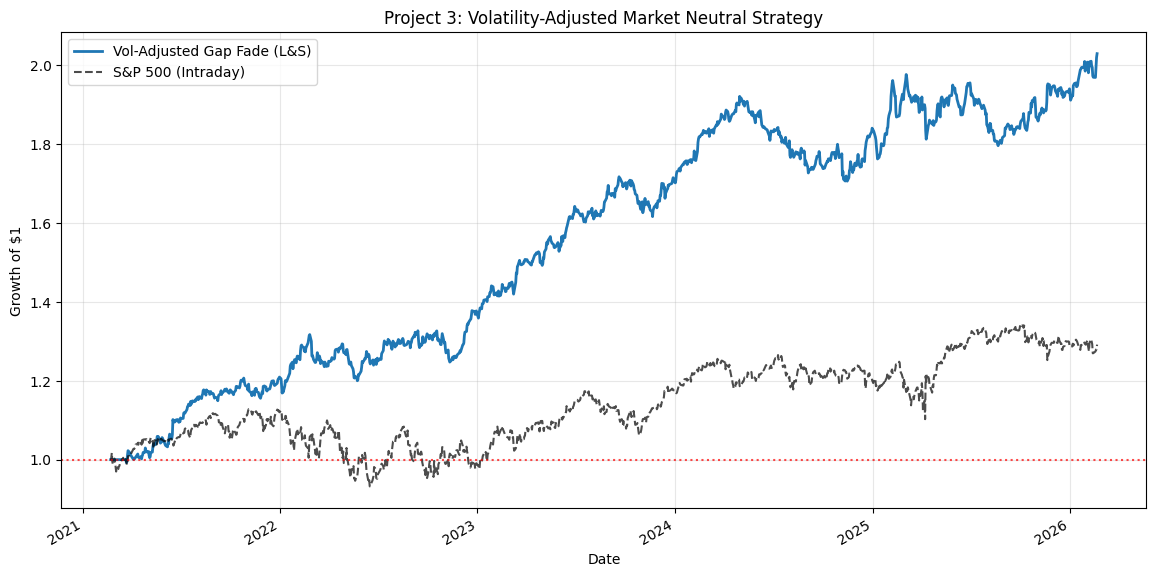

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# --- 1. DATA SETUP ---
tickers = [
    "PPG", "DG", "TPL", "RF", "CHD", "EIX", "LH", "DRI", "CDW", "WAT",
    "L", "DVN", "TYL", "SBAC", "ON", "IP", "WST", "LULU", "DLTR", "NI",
    "ZBH", "NVR", "KEY", "DGX", "RL", "SW", "TRMB", "BG", "GPN", "IT",
    "J", "PFG", "CPAY", "INCY", "TSN", "AMCR", "CHRW", "CTRA", "GDDY", "^GSPC"
]

print("Downloading Data...")
raw_data = yf.download(tickers, period='5y', interval='1d', auto_adjust=True, progress=False)

prices_close = raw_data['Close'].dropna(axis=1)
prices_open = raw_data['Open'][prices_close.columns]

asset_list = [c for c in prices_close.columns if c != '^GSPC']

# --- 2. THE QUANTITATIVE FILTERS ---
# 1. Calculate 20-Day Historical Volatility (Standard Deviation of daily returns)
daily_returns = prices_close[asset_list].pct_change()
volatility_20d = daily_returns.rolling(window=20).std()

# 2. Calculate the Overnight Gap % (Today's Open vs Yesterday's Close)
overnight_gap = (prices_open[asset_list] - prices_close[asset_list].shift(1)) / prices_close[asset_list].shift(1)

# 3. THE ALPHA SIGNAL: Volatility-Adjusted Gap (Z-Score)
gap_z_score = overnight_gap / volatility_20d.shift(1)

# Execution PnL (Open-to-Close)
trade_returns = (prices_close[asset_list] - prices_open[asset_list]) / prices_open[asset_list]

# --- 3. DYNAMIC MARKET NEUTRAL ALLOCATION ---
weights_list = []
daily_portfolio_returns = []
trade_log_data = [] # <--- New Trade Log List

print("Running Volatility-Adjusted Tournament...")

for i in range(len(prices_close)):
    # Need 20 days to build the initial volatility window
    if i < 21:
        daily_portfolio_returns.append(0)
        weights_list.append(pd.Series(0, index=asset_list))
        continue

    today_gap_z = gap_z_score.iloc[i]
    today_weights = pd.Series(0.0, index=asset_list)
    current_date = prices_close.index[i].date()

    if not today_gap_z.isna().all():
        # FIND RELATIVE EXTREMES
        top_5_up = today_gap_z.nlargest(5).index
        top_5_down = today_gap_z.nsmallest(5).index

        # ALLOCATION: Gross Exposure 100% (50% Long, 50% Short)
        today_weights[top_5_up] = -0.10   # Fade the extreme relative gap ups
        today_weights[top_5_down] = 0.10  # Buy the extreme relative gap downs

        # --- LOG TRADES FOR TRANSPARENCY ---
        for stock in top_5_down:
            trade_log_data.append({
                "Date": current_date,
                "Action": "Long (Buy Panic)",
                "Stock": stock,
                "Gap Z-Score": round(today_gap_z[stock], 2),
                "Target Weight": "+10%"
            })

        for stock in top_5_up:
            trade_log_data.append({
                "Date": current_date,
                "Action": "Short (Fade Euphoria)",
                "Stock": stock,
                "Gap Z-Score": round(today_gap_z[stock], 2),
                "Target Weight": "-10%"
            })

    # Execute at the Open, hold to Close
    daily_return = (today_weights * trade_returns.iloc[i]).sum()
    daily_portfolio_returns.append(daily_return)
    weights_list.append(today_weights)

# --- 4. RESULTS & ANALYTICS ---
strat_cum_ret = (1 + pd.Series(daily_portfolio_returns, index=prices_close.index)).cumprod()
sp500_intra_ret = (prices_close['^GSPC'] - prices_open['^GSPC']) / prices_open['^GSPC']
sp500_cum_ret = (1 + sp500_intra_ret).cumprod()

active_rets = pd.Series(daily_portfolio_returns)[pd.Series(daily_portfolio_returns) != 0]
sharpe = (active_rets.mean() / active_rets.std()) * np.sqrt(252) if not active_rets.empty else 0
win_rate = (active_rets > 0).sum() / len(active_rets)

print("\n--- Strategy Performance Summary ---")
print(f"Final Portfolio Value: ${strat_cum_ret.iloc[-1] * 10000:,.2f}")
print(f"Annualized Sharpe Ratio: {sharpe:.2f}")
print(f"Accuracy (Win Rate): {win_rate * 100:.2f}%")

# Convert log to DataFrame and display the last 20 trades (2 days worth)
df_trade_log = pd.DataFrame(trade_log_data)
print("\n--- Trade Log: Daily 10-Stock Market Neutral Allocation (Tail) ---")
display(df_trade_log.tail(20))

# Plotting
plt.figure(figsize=(14, 7))
strat_cum_ret.plot(label='Vol-Adjusted Gap Fade (L&S)', linewidth=2)
sp500_cum_ret.plot(label='S&P 500 (Intraday)', alpha=0.7, color='black', linestyle='--')

plt.title('Project 3: Volatility-Adjusted Market Neutral Strategy')
plt.ylabel('Growth of $1')
plt.axhline(1.0, color='red', linestyle=':', alpha=0.7)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()